In [1]:
# external imports
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from pathlib import Path
from typing import List
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
    """Load and combine multiple experiment CSVs. Do simple data processing for later convenience"""
    dfs = []
    for path in csv_paths:
        df = pd.read_csv(path, index_col=0)
        df['source_file'] = Path(path).parent.name  # track which experiment it came from
        dfs.append(df)
    
    combined = pd.concat(dfs, ignore_index=True)
    
    # add in diff representations of red params for convenience
    combined[['resizeTrigger', 'sizeLimit']] = combined['reduce_triggerSz_sizeLim'].str.strip('()').str.split(',', expand=True).astype(int)
    combined['gap_size_range_tuple'] = combined['gap_size_range'].apply(ast.literal_eval)
    combined['reduce_triggerSz_sizeLim_tuple'] = combined['reduce_triggerSz_sizeLim'].apply(ast.literal_eval)
    combined['time_norm'] = combined['sumMetrics_time_mean'] / combined['sumMetrics_time_mean'].max()
    combined['coverage_norm'] = combined['result_coverage_mean'] / combined['result_coverage_mean'].max()
    combined['efficiency'] = combined['coverage_norm'] / combined['time_norm']
    return combined

In [2]:
csv = ['data/results/2359006339/ni_sweeping400/ni15_red500_250_sweep/results_sd2359006339.csv', 'data/results/2359006339/ni_sweeping400/ni15_red500_100_sweep/results_sd2359006339.csv', 'data/results/2359006339/ni_sweeping400/ni15_red500_10_sweep/results_sd2359006339.csv', 'data/results/2359006339/ni_sweeping400/ni15_red150_100_sweep/results_sd2359006339.csv', 'data/results/2359006339/ni_sweeping400/ni15_red150_10_sweep/results_sd2359006339.csv', 'data/results/2359006339/ni_sweeping400/ni15_red70_50_sweep/results_sd2359006339.csv', 'data/results/2359006339/ni_sweeping400/ni15_red15_10_sweep/results_sd2359006339.csv', 'data/results/2359006339/ni_sweeping400/ni15_red3_1_sweep/results_sd2359006339.csv']

df = load_all_csvs(csv)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   master_seed                      56 non-null     int64  
 1   data_type                        56 non-null     object 
 2   num_trials                       56 non-null     int64  
 3   dataset_size                     56 non-null     int64  
 4   uncertain_ratio                  56 non-null     float64
 5   interval_size_range              56 non-null     object 
 6   mult_size_range                  56 non-null     object 
 7   num_intervals                    56 non-null     int64  
 8   start_interval_range             56 non-null     object 
 9   gap_size                         0 non-null      float64
 10  interval_width                   0 non-null      float64
 11  num_intervals_range              0 non-null      float64
 12  gap_size_range          

In [4]:
a = df

In [5]:
def enrich(df):
    df["time_speedup"] = df["sum_time_mean"] / df["p_sum_time_mean"]
    df["time_delta"] = df["p_sum_time_mean"] - df["sum_time_mean"]
    
    df["coverage_loss"] = df["result_coverage_mean"] - df["p_result_coverage_mean"]
    df["coverage_ratio"] = df["p_result_coverage_mean"] / df["result_coverage_mean"]
    return df

In [6]:
a = enrich(a)
a

,master_seed,data_type,num_trials,dataset_size,uncertain_ratio,interval_size_range,mult_size_range,num_intervals,start_interval_range,gap_size,interval_width,num_intervals_range,gap_size_range,interval_width_range,reduce_triggerSz_sizeLim,independent_variable,distribution,row_count,min_time_mean,min_time_std,max_time_mean,max_time_std,sum_time_mean,sum_time_std,sumMetrics_time_mean,sumMetrics_time_std,p_min_time_mean,p_min_time_std,p_max_time_mean,p_max_time_std,p_sum_time_mean,p_sum_time_std,p_sumMetrics_time_mean,p_sumMetrics_time_std,sum_results,reduce_calls_mean,max_interval_count_mean,total_interval_count_mean,combine_calls_mean,result_size_mean,minEffectiveIntervalCountMean,convergedToTotSize,result_coverage_mean,p_sum_results,p_reduce_calls_mean,p_max_interval_count_mean,p_total_interval_count_mean,p_combine_calls_mean,p_result_size_mean,p_minEffectiveIntervalCountMean,p_convergedToTotSize,p_result_coverage_mean,source_file,resizeTrigger,sizeLimit,gap_size_range_tuple,reduce_triggerSz_sizeLim_tuple,time_norm,coverage_norm,efficiency,time_speedup,time_delta,coverage_loss,coverage_ratio
0,2359006339,set,3,400,0.0,"(1, 100000)","(1, 5)",1,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(1, 2)","(500, 250)",num_intervals,DistributionType.UNIFORM,400.0,0.566667,0.208145,0.357000,0.012193,0.287333,0.024784,NaN,NaN,0.432333,0.087606,0.375667,0.016049,0.312333,0.001886,NaN,NaN,"[NumericRange(205852, 206253, '[)')]",0.0,1.0,400.0,400.0,1.0,1.0,401.0,401.0,"[NumericRange(63473, 63667, '[)')]",0.0,1.0,193.0,193.0,1.0,1.0,194.0,194.0,ni15_red500_250_sweep,500,250,"(2000, 2001)","(500, 250)",NaN,0.000036,NaN,0.919957,0.025000,207.0,0.483791
1,2359006339,set,3,400,0.0,"(1, 100000)","(1, 5)",2,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(1, 2)","(500, 250)",num_intervals,DistributionType.UNIFORM,400.0,4.676000,0.131273,0.556333,0.053481,6.731000,0.132144,NaN,NaN,0.921000,0.012083,0.726333,0.072638,3.329667,0.053325,NaN,NaN,"[NumericRange(198221, 500773, '[)'), NumericRa...",246.0,996.0,190762.0,400.0,250.0,250.0,402401.0,402401.0,"[NumericRange(198221, 198622, '[)'), NumericRa...",72.0,992.0,123286.0,400.0,204.0,204.0,81804.0,81804.0,ni15_red500_250_sweep,500,250,"(2000, 2001)","(500, 250)",NaN,0.035909,NaN,2.021524,-3.401333,320597.0,0.203290
2,2359006339,set,3,400,0.0,"(1, 100000)","(1, 5)",3,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(1, 2)","(500, 250)",num_intervals,DistributionType.UNIFORM,400.0,8.542000,0.275773,0.627667,0.011146,13.285667,0.796369,NaN,NaN,6.226333,1.966257,0.978667,0.082681,11.806000,2.093503,NaN,NaN,"[NumericRange(212808, 1315760, '[)'), NumericR...",352.0,1485.0,280329.0,400.0,250.0,250.0,1202801.0,1202801.0,"[NumericRange(212808, 887545, '[)'), NumericRa...",308.0,1488.0,237475.0,400.0,250.0,250.0,774337.0,774337.0,ni15_red500_250_sweep,500,250,"(2000, 2001)","(500, 250)",NaN,0.107335,NaN,1.125332,-1.479667,428464.0,0.643778
3,2359006339,set,3,400,0.0,"(1, 100000)","(1, 5)",4,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(1, 2)","(500, 250)",num_intervals,DistributionType.UNIFORM,400.0,13.117667,0.295483,0.744667,0.022050,17.025333,0.351134,NaN,NaN,9.428667,0.090116,1.114000,0.097611,15.546333,0.518681,NaN,NaN,"[NumericRange(195559, 2098911, '[)'), NumericR...",376.0,1984.0,377248.0,400.0,250.0,250.0,2003201.0,2003201.0,"[NumericRange(195559, 1716720, '[)'), NumericR...",365.0,1872.0,330046.0,400.0,250.0,250.0,1621010.0,1621010.0,ni15_red500_250_sweep,500,250,"(2000, 2001)","(500, 250)",NaN,0.178761,NaN,1.095135,-1.479000,382191.0,0.809210
4,2359006339,set,3,400,0.0,"(1, 100000)","(1, 5)",6,"(1, 1000)",NaN,NaN,NaN,"(2000, 2001)","(1, 2)","(500, 250)",num_intervals,DistributionType.UNIFORM,400.0,22.362000,0.171478,0.962333,0.013597,30.361333,3.027861,NaN,NaN,18.649667,0.110978,1.377000,0.007789,27.613000,1.449826,NaN,NaN,"[NumericRange(208530, 3712682, '[)'), NumericR...",390.0,2916.0,573900.0,400.0,250.0,250.0,3604001.0,3604001.0,"[NumericRange(208530, 3306479, '[)'), NumericR...",389.0,2700.0,522765.0,400.0,250.0,250.0,3197798

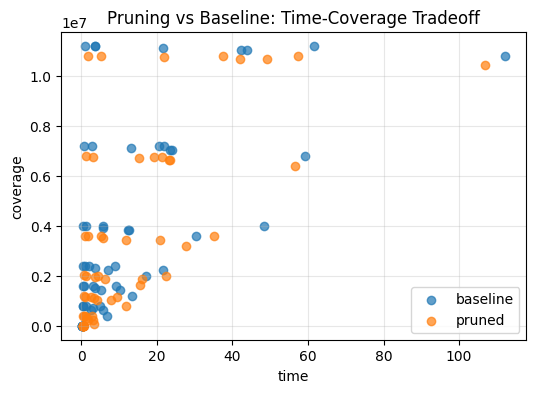

In [7]:
def plot_prune(df):
    plt.figure(figsize=(6,4))

    # baseline
    plt.scatter(
        df["sum_time_mean"],
        df["result_coverage_mean"],
        label="baseline",
        alpha=0.7
    )
    
    # pruned
    plt.scatter(
        df["p_sum_time_mean"],
        df["p_result_coverage_mean"],
        label="pruned",
        alpha=0.7
    )
    
    plt.xlabel("time")
    plt.ylabel("coverage")
    plt.title("Pruning vs Baseline: Time-Coverage Tradeoff")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_prune(a)

In [14]:
csv2=['data/results/2519684606/ni_sweeping100/ni3_red500_250_sweep/results_sd2519684606.csv', 'data/results/2519684606/ni_sweeping100/ni3_red500_100_sweep/results_sd2519684606.csv', 'data/results/2519684606/ni_sweeping100/ni3_red500_10_sweep/results_sd2519684606.csv', 'data/results/2519684606/ni_sweeping100/ni3_red150_100_sweep/results_sd2519684606.csv', 'data/results/2519684606/ni_sweeping100/ni3_red150_10_sweep/results_sd2519684606.csv', 'data/results/2519684606/ni_sweeping100/ni3_red70_50_sweep/results_sd2519684606.csv', 'data/results/2519684606/ni_sweeping100/ni3_red15_10_sweep/results_sd2519684606.csv']
df = load_all_csvs(csv2)

In [73]:
# def prune_alpha(df):
#     alphas = sorted(df["prune_alpha"].unique())
#     n = len(alphas)
    
#     fig, axes = plt.subplots(1, 1, figsize=(4*n, 4), sharex=True, sharey=True)
    
#     if n == 1:
#         axes = [axes]
    
#     for ax, alpha in zip(axes, alphas):
#         sub_df = df[df["prune_alpha"] == alpha]
    
#         # baseline
#         ax.scatter(
#             sub_df["sum_time_mean"],
#             sub_df["result_coverage_mean"],
#             color="gray",
#             alpha=0.6,
#             label="baseline",
#             s=40
#         )
    
#         # pruned
#         ax.scatter(
#             sub_df["p_sum_time_mean"],
#             sub_df["p_result_coverage_mean"],
#             label=f"pruned",
#             s=60
#         )
    
#         ax.set_title(f"α = {alpha}")
#         ax.set_xlabel("time")
#         ax.set_ylabel("coverage")
#         ax.grid(True, alpha=0.3)
    
#     # clean legend (avoid duplicates)
#     handles, labels = axes[0].get_legend_handles_labels()
#     fig.legend(handles, labels, loc="upper right")
    
#     plt.tight_layout()
#     plt.show()

# prune_alpha(df)



def prune_results(df):
    fig, ax = plt.subplots(figsize=(6, 5))

    # baseline
    ax.scatter(
        df["sum_time_mean"],
        df["result_coverage_mean"],
        color="gray",
        alpha=0.6,
        label="baseline",
        s=40
    )

    # pruned
    ax.scatter(
        df["p_sum_time_mean"],
        df["p_result_coverage_mean"],
        label="pruned",
        s=60
    )

    ax.set_xlabel("time")
    ax.set_ylabel("coverage")
    ax.set_title("Baseline vs Pruned Performance where (a < b) is not false")
    ax.grid(True, alpha=0.3)

    ax.legend()
    plt.tight_layout()
    plt.show()

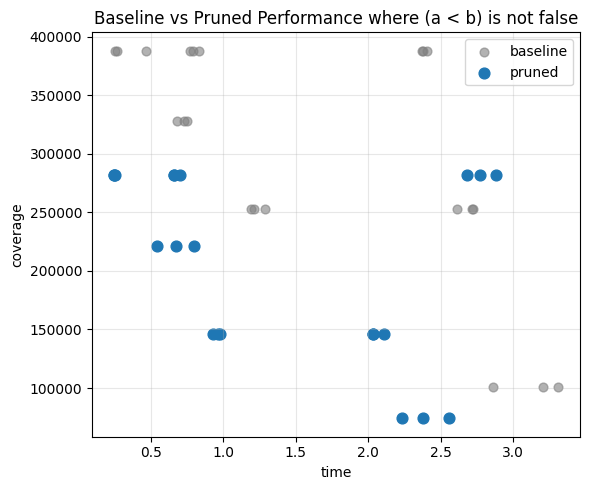

In [25]:
prune_results(df)

In [69]:
def base_vs_pruned(df):
    df = df.copy()
    df["reduce_key"] = df["reduce_triggerSz_sizeLim_tuple"].astype(str)

    keys = sorted(df["reduce_key"].unique())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for k in keys:
        g = df[df["reduce_key"] == k]

        ax1.scatter(
            g["sum_time_mean"],
            g["result_coverage_mean"],
            alpha=0.7,
            s=40,
            label=k,
        )

    ax1.set_title("Baseline (WHERE a < b is not false)")
    ax1.set_xlabel("time")
    ax1.set_ylabel("coverage")
    ax1.grid(True, alpha=0.3)

    for k in keys:
        g = df[df["reduce_key"] == k]

        ax2.scatter(
            g["p_sum_time_mean"],
            g["p_result_coverage_mean"],
            alpha=0.7,
            s=40,
            label=k,
        )

    ax2.set_title("Pruned (prune_lt(a,b, false))")
    ax2.set_xlabel("time")
    ax2.grid(True, alpha=0.3)

    ax2.set_xlim(ax1.get_xlim())
    ax2.set_ylim(ax1.get_ylim())

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="reduce params",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()
    plt.savefig()

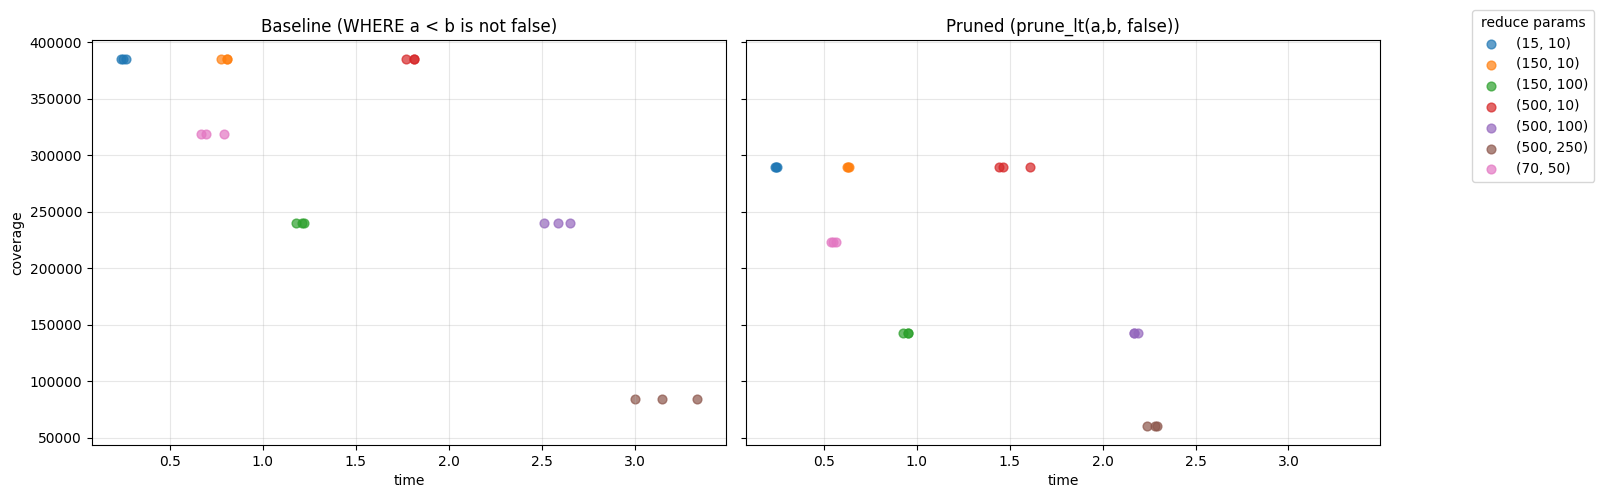

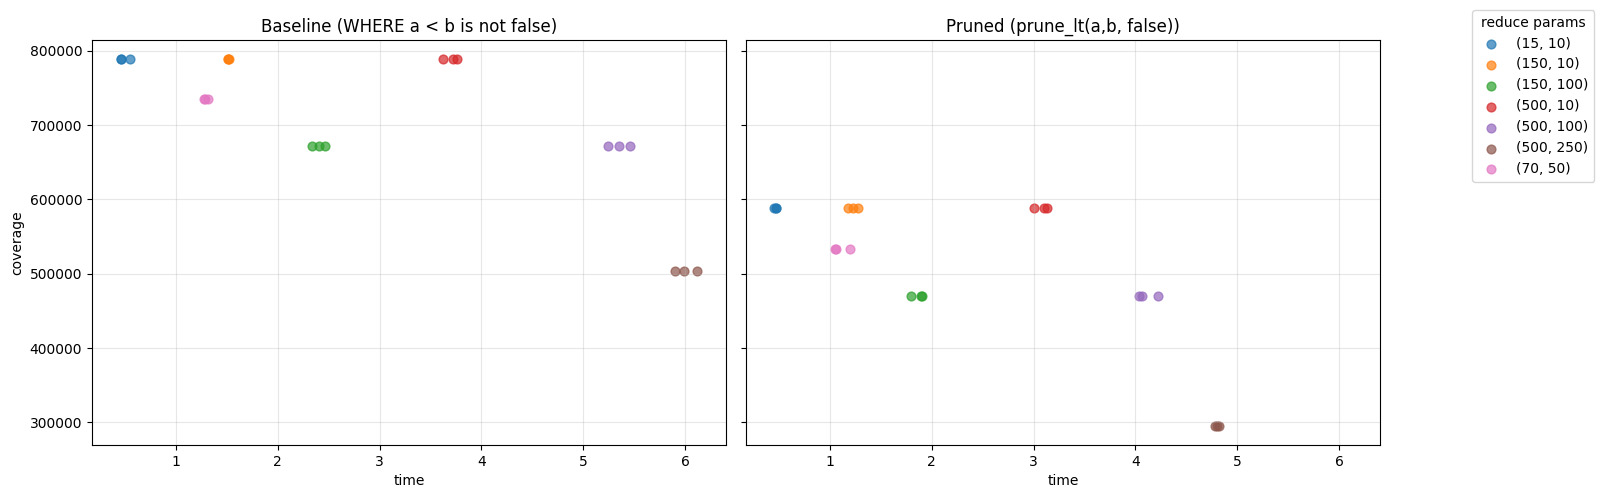

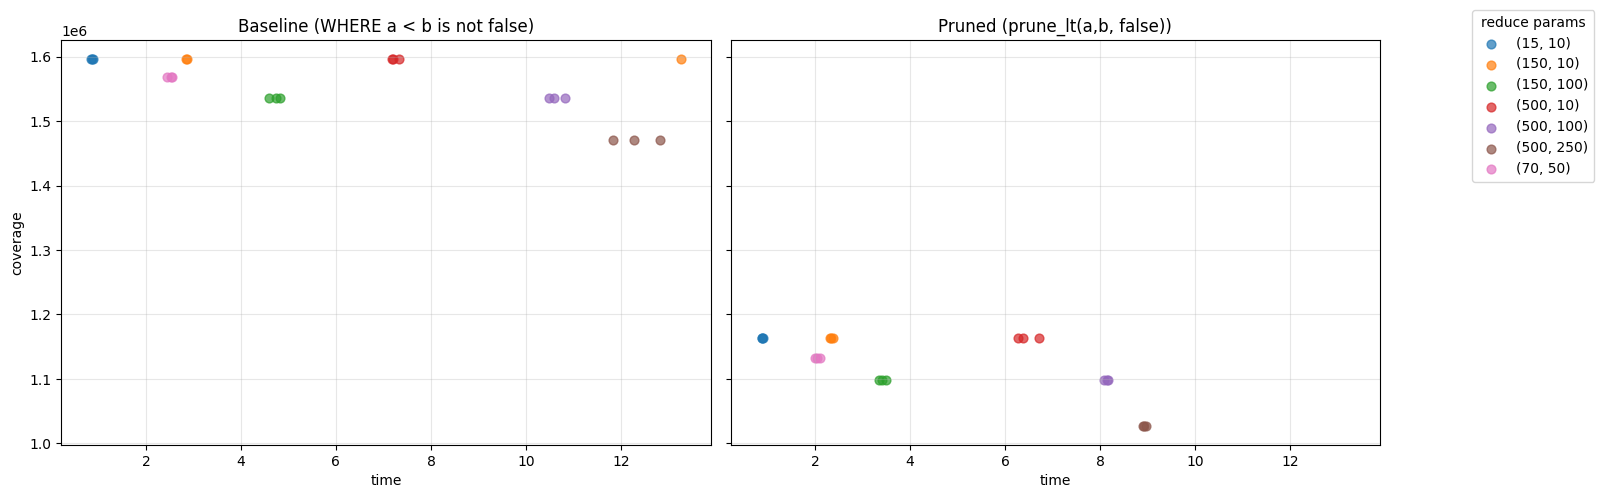

In [76]:
df100=load_all_csvs(['data/results/2521009940/ni_sweeping100/ni3_red500_250_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping100/ni3_red500_100_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping100/ni3_red500_10_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping100/ni3_red150_100_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping100/ni3_red150_10_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping100/ni3_red70_50_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping100/ni3_red15_10_sweep/results_sd2521009940.csv'])
base_vs_pruned(df100)

df200=load_all_csvs( ['data/results/2521009940/ni_sweeping200/ni3_red500_250_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping200/ni3_red500_100_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping200/ni3_red500_10_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping200/ni3_red150_100_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping200/ni3_red150_10_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping200/ni3_red70_50_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping200/ni3_red15_10_sweep/results_sd2521009940.csv'])
base_vs_pruned(df200)

df400= load_all_csvs(['data/results/2521009940/ni_sweeping400/ni3_red500_250_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping400/ni3_red500_100_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping400/ni3_red500_10_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping400/ni3_red150_100_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping400/ni3_red150_10_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping400/ni3_red70_50_sweep/results_sd2521009940.csv', 'data/results/2521009940/ni_sweeping400/ni3_red15_10_sweep/results_sd2521009940.csv'])
base_vs_pruned(df400)